In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
from torch.utils.data import DataLoader, Subset
from torchvision import models, datasets, transforms

DATA_DIR = '/kaggle/input/datasets/oxcdcd/cifar10/cifar10' 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

final_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2470, 0.2435, 0.2616))
])

# Load Train and Test folders
train_full = datasets.ImageFolder(root=os.path.join(DATA_DIR, 'train'), transform=final_transform)
test_set = datasets.ImageFolder(root=os.path.join(DATA_DIR, 'test'), transform=final_transform)



Using device: cuda


In [2]:
# Create Validation split from the Train folder (90% train, 10% val)
num_train = len(train_full)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(0.1 * num_train))
train_idx, val_idx = indices[split:], indices[:split]

train_set = Subset(train_full, train_idx)
val_set = Subset(train_full, val_idx)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

# 4. MODEL INITIALIZATION
model = models.resnet18(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [3]:
# 5. TRAINING LOOP
epochs = 30
history = {'loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    
    # Validation phase
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
    
    epoch_loss = running_loss / len(train_idx)
    epoch_acc = 100 * correct / len(val_idx)
    history['loss'].append(epoch_loss)
    history['val_acc'].append(epoch_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Val Acc: {epoch_acc:.2f}%")

# 6. FINAL EVALUATION & ASSET SAVING
model.eval()
test_correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        test_correct += (model(images).argmax(dim=1) == labels).sum().item()

print(f"\nFinal Test Accuracy: {100 * test_correct / len(test_set):.2f}%")

# Save plots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss', color='red')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='blue')
plt.title('Accuracy History')
plt.legend()

plt.show()
# Save weights and metadata
torch.save(model.state_dict(), os.path.join("/kaggle/working/", 'resnet18_weights.pth'))

Epoch [1/30] Loss: 1.3911 Val Acc: 55.20%
Epoch [2/30] Loss: 1.0006 Val Acc: 64.52%
Epoch [3/30] Loss: 0.8223 Val Acc: 68.60%
Epoch [4/30] Loss: 0.6927 Val Acc: 70.84%
Epoch [5/30] Loss: 0.5764 Val Acc: 70.20%
Epoch [6/30] Loss: 0.4870 Val Acc: 72.52%
Epoch [7/30] Loss: 0.3969 Val Acc: 72.74%
Epoch [8/30] Loss: 0.3266 Val Acc: 74.18%
Epoch [9/30] Loss: 0.2554 Val Acc: 74.20%
Epoch [10/30] Loss: 0.2107 Val Acc: 73.70%
Epoch [11/30] Loss: 0.1769 Val Acc: 74.06%
Epoch [12/30] Loss: 0.1444 Val Acc: 72.54%
Epoch [13/30] Loss: 0.1300 Val Acc: 74.44%
Epoch [14/30] Loss: 0.1180 Val Acc: 73.54%
Epoch [15/30] Loss: 0.0979 Val Acc: 74.42%
Epoch [16/30] Loss: 0.0918 Val Acc: 74.24%
Epoch [17/30] Loss: 0.0809 Val Acc: 73.70%
Epoch [18/30] Loss: 0.0833 Val Acc: 74.26%
Epoch [19/30] Loss: 0.0736 Val Acc: 73.40%


KeyboardInterrupt: 


Final Test Accuracy: 75.01%


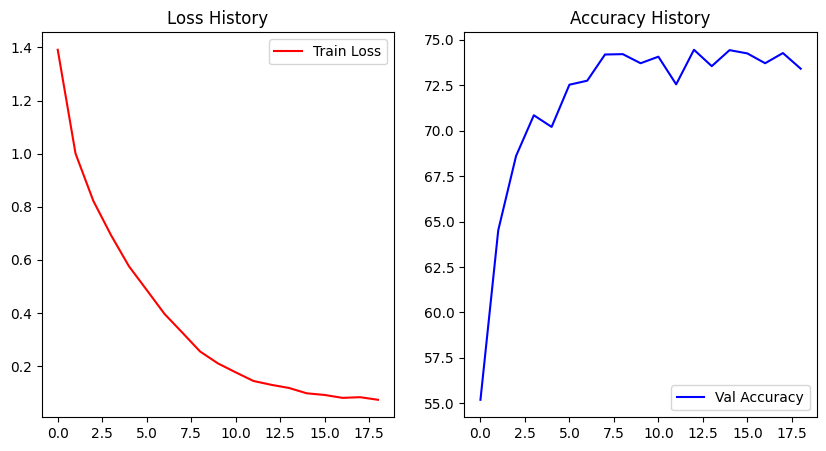

In [4]:
# 6. FINAL EVALUATION & ASSET SAVING
model.eval()
test_correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        test_correct += (model(images).argmax(dim=1) == labels).sum().item()

print(f"\nFinal Test Accuracy: {100 * test_correct / len(test_set):.2f}%")

# Save plots
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss', color='red')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='blue')
plt.title('Accuracy History')
plt.legend()

plt.show()
# Save weights and metadata
torch.save(model.state_dict(), os.path.join("/kaggle/working/", 'resnet18_weights.pth'))